In [12]:
# Capstone -- function 1 (2D)

import numpy as np
import matplotlib.pyplot as plt

from scipy.spatial import Delaunay, ConvexHull

from bayes_tools import (
    load_collected, save_proposal,
    fitting,
    normalize, initial_bounds, validate_bounds_consistency,
    generate_next_point, ucb_acquisition,
    append_observations, fit_gp, get_length_scales, loo_predictions,
    fit_y_scale, to_scaled_units,
    compare_kappa_proposals, print_kappa_comparison,
)
from viz_tools import plot_2d_bo, plot_loo_calibration, plot_kappa_sensitivity


# Function 1

2D. We model `log10|y|` rather than `y`, and we search the observed bounding box rather than the padded box. The `y` magnitudes here span more than a hundred orders of magnitude and this is how we got a surrogate that works at all.

Using kappa==3 given the week four output pushes the proposed X values to the extreme corner of the 0.0->1.0 bounding box. Therefore, reducing kappa to 2 this week for a more reasonable response. 

## Why I model `log10|y|`

After `fit_gp`'s internal `normalize_y`, eleven of my twelve observations collapse to the *identical* value `0.301511` — so the GP was seeing two distinct numbers, not twelve. Leave-one-out on `y` gives R² **−0.56** and orders only **42%** of point pairs correctly, worse than a coin flip. On `log10|y|` I get R² **+0.68**, **86%** of pairs ordered right, and neither ARD length-scale pinned.

I keep the old linearly-rescaled `y` around as the baseline the new target is scored against. It can't help: dividing by the standard deviation preserves every ratio, so it leaves the dynamic range exactly where it was.

## Note: UCB here is sign-blind

`log10|y|` models **magnitude**, so UCB maximises `|y|` — but I want `max y`, and my largest `|y|` is **negative** (`−3.6e-3` at (0.650114, 0.681526), 13 orders above anything else). So the surrogate's own peak is somewhere I do not want to go, and UCB cannot tell.

| `kappa` | proposal | distance to the negative peak |
|---|---|---|
| 0.5 | `[0.6426, 0.6086]` | **0.073** — effectively resampling it |
| 1.0 | `[0.6512, 0.5900]` | 0.092 |
| 2.0 | `[0.6673, 0.5618]` | 0.121 |
| 3.0 | `[0.6770, 0.5407]` | 0.143 |
| ≥ 4.0 | `[0.0825, 0.8799]` | 0.601 — **both axes on the box edge** |

I re-measured this after week 4's observation at `[0.53388, 0.493601]` (`y = 8.27e-14`) landed almost exactly on the previous week's proposal. That single point moved the mode switch from `kappa 8 → 10` down to `kappa 3 → 4`, and pulled `kappa=3`'s own proposal from 0.221 to 0.143 from the negative peak — *closer* to the wrong-sign region, not farther. So my window is squeezed from both sides and `KAPPA = 3.0` now sits on the last usable step rather than comfortably inside. I re-run this sweep every week instead of assuming the margin holds.

Backtesting `kappa` and the other acquisition families still puts `ucb` at `kappa=3` ahead of the alternatives here.

In [13]:
X_initial = np.load("initial_data/function_1/initial_inputs.npy")
y_initial = np.load("initial_data/function_1/initial_outputs.npy")
D = X_initial.shape[1]

assert D == 2, f"Expected a 2D problem, got {D}D input -- check the loaded file."

# Loaded once and never modified.
new_X = np.empty((0, D))
new_y = np.empty((0,))


## Update this once per week

Include the new X and y values from the previous week

In [14]:
# Collected observations, from weekly_data/function_1/ (weeks 2-4, oldest
# first). Run record_results.py before opening this notebook so the results
# are already in place. pending_X holds a proposal with no result yet and is
# never passed to the model.

new_X, new_y, pending_X = load_collected(1, D)

print("observations collected so far:", len(new_y))


weekly store: 4 resulted observation(s), none pending
observations collected so far: 4


## Build the full dataset (initial + everything collected so far)

In [15]:
X, y = append_observations(X_initial, y_initial, new_X, new_y)

print("X_initial shape:", X_initial.shape, "| y_initial shape:", y_initial.shape)
print("new_X shape:     ", new_X.shape, "| new_y shape:     ", new_y.shape)
print("combined X shape:", X.shape, "| combined y shape:", y.shape)

print("\nX range per dimension:")
print("  min:", X.min(axis=0))
print("  max:", X.max(axis=0))
print("y range:", y.min(), "to", y.max())

bounds_standard = initial_bounds(X_initial, pad_fraction=1.0, lower_limit=0.0,
                        upper_limit=1.0)
validate_bounds_consistency(X, bounds_standard)


bounds_box = np.column_stack([X.min(axis=0), X.max(axis=0)])
validate_bounds_consistency(X, bounds_box)

bounds = bounds_box

print("\nstandard bounds (pad_fraction=1.0):\n", np.round(bounds_standard, 4))
print("\nobserved bounding box (USED THIS WEEK):\n", np.round(bounds_box, 4))

print("\nfraction of each standard-bounds axis actually covered by data:")
frac = 1.0
for d in range(D):
    f = (X[:, d].max() - X[:, d].min()) / (bounds_standard[d, 1] - bounds_standard[d, 0])
    frac *= f
    print(f"  x{d}: {f:.1%}")
print(f"  -> {frac:.1%} of the standard box by volume; the rest is extrapolation")

# How loose is the box as a stand-in for "where my data actually is"?
hull = Delaunay(X)
box_volume = float(np.prod(bounds_box[:, 1] - bounds_box[:, 0]))
ch_volume = ConvexHull(X).volume
print(f"\nbounding box area {box_volume:.5f} | convex hull area {ch_volume:.5f}"
      f" ({ch_volume / box_volume:.1%} of the box)")
print(f"{len(ConvexHull(X).vertices)} of {len(X)} observations are hull vertices")


X_initial shape: (10, 2) | y_initial shape: (10,)
new_X shape:      (4, 2) | new_y shape:      (4,)
combined X shape: (14, 2) | combined y shape: (14,)

X range per dimension:
  min: [0.08250725 0.07872278]
  max: [0.885365  0.8798981]
y range: -0.0036060626443634764 to 6.881840815488692e-08

standard bounds (pad_fraction=1.0):
 [[0. 1.]
 [0. 1.]]

observed bounding box (USED THIS WEEK):
 [[0.0825 0.8854]
 [0.0787 0.8799]]

fraction of each standard-bounds axis actually covered by data:
  x0: 80.3%
  x1: 80.1%
  -> 64.3% of the standard box by volume; the rest is extrapolation

bounding box area 0.64323 | convex hull area 0.43389 (67.5% of the box)
9 of 14 observations are hull vertices


## Three candidate modelling targets

The first decision each week is *what to model*, not which acquisition to use — the dynamic range is the dominant problem.

`|y|` spans 121 orders of magnitude. In float64 every observation except the single value at −3.6e-3 is numerically **zero** relative to it, which is why a GP fit on `y` cannot tell my incumbent best (7.7e-16) from my worst point on record (3.3e-124).

I build three targets:

- **`y_scaled`** — `y` over its standard deviation. The previous choice, kept only as the baseline. Being a linear rescale it changes nothing about the dynamic range.
- **`y_logmag`** — `log10|y|`, floored at `LOG_FLOOR` so an exact zero stays representable. This is the live target.
- **`y_sign`** — `sign(y)` as ±1, so we can check whether the sign half of the decomposition is modellable yet.

In [16]:
# log10|y| is undefined at y == 0, so I floor the magnitude. -130 sits below the
# smallest observed log10|y| (-123.5), so nothing real is clipped -- it just
# means an exact zero would not break this.
LOG_FLOOR = -130.0

y_sign = np.sign(y)
y_logmag = np.log10(np.maximum(np.abs(y), 10.0 ** LOG_FLOOR))

# The old parameterisation, kept ONLY as the baseline scored in the next cell.
# Nothing downstream uses it -- our live unit system is log10|y|.
y_scale = fit_y_scale(y)
y_scaled = to_scaled_units(y, y_scale)

print("=== let's show the huge range of magnitude ===")
nz = np.abs(y[y != 0])
print(f"|y| spans log10 {np.log10(nz).min():.1f} to {np.log10(nz).max():.1f}"
      f"  -> {np.log10(nz).max() - np.log10(nz).min():.0f} orders of magnitude")
print(f"signs: {(y > 0).sum()} positive, {(y < 0).sum()} negative, {(y == 0).sum()} zero")
print(f"largest |y|:  {np.abs(y).max():.4e}  (sign {'+' if y[np.argmax(np.abs(y))] > 0 else '-'})")
print(f"incumbent y:  {y.max():.4e}")
print(f"ratio:        {np.abs(y).max() / abs(y.max()):.3e}"
      f"  -> the incumbent is {np.log10(np.abs(y).max() / abs(y.max())):.0f} orders below the"
      " largest magnitude, so in float64 it is indistinguishable from 0 to a GP fit on y")

print("\n=== the three targets ===")
print(f"y_scaled : range [{y_scaled.min():+.4g}, {y_scaled.max():+.4g}]"
      f"   (y_scale = {y_scale:.6g}; a LINEAR rescale -- dynamic range unchanged)")
print(f"y_logmag : range [{y_logmag.min():+.2f}, {y_logmag.max():+.2f}]"
      f"   spread {y_logmag.max() - y_logmag.min():.1f}")
print(f"y_sign   : {int((y_sign > 0).sum())} at +1, {int((y_sign < 0).sum())} at -1")

print("\n=== the data, ranked by y (what we actually maximise) ===")
print(f"{'rank':>4} {'x0':>10} {'x1':>10} {'y':>13} {'sign':>5} {'log10|y|':>9}")
for r, i in enumerate(np.argsort(-y)):
    print(f"{r + 1:>4} {X[i, 0]:>10.6f} {X[i, 1]:>10.6f} {y[i]:>13.4e}"
          f" {'+' if y[i] > 0 else '-':>5} {y_logmag[i]:>9.2f}")

# Landmarks reused below. They are NOT the same point, and that is my whole
# difficulty here: the magnitude peak -- what log10|y| makes the GP chase -- is
# negative, while the incumbent I am trying to beat is positive.
i_pos_max = int(np.argmax(y))          # largest y  (the incumbent)
i_abs_max = int(np.argmax(np.abs(y)))  # largest |y| (the magnitude peak)
p_pos, neg_peak = X[i_pos_max], X[i_abs_max]

print(f"\nincumbent (max y)       : {np.round(p_pos, 6)}  y = {y[i_pos_max]:+.4e}")
print(f"magnitude peak (max |y|): {np.round(neg_peak, 6)}  y = {y[i_abs_max]:+.4e}"
      "   <- NEGATIVE")
print(f"separation: {np.linalg.norm(p_pos - neg_peak):.4f}")


=== let's show the huge range of magnitude ===
|y| spans log10 -123.5 to -2.4  -> 121 orders of magnitude
signs: 10 positive, 4 negative, 0 zero
largest |y|:  3.6061e-03  (sign -)
incumbent y:  6.8818e-08
ratio:        5.240e+04  -> the incumbent is 5 orders below the largest magnitude, so in float64 it is indistinguishable from 0 to a GP fit on y

=== the three targets ===
y_scaled : range [-3.883, +7.41e-05]   (y_scale = 0.000928704; a LINEAR rescale -- dynamic range unchanged)
y_logmag : range [-123.48, -2.44]   spread 121.0
y_sign   : 10 at +1, 4 at -1

=== the data, ranked by y (what we actually maximise) ===
rank         x0         x1             y  sign  log10|y|
   1   0.677043   0.540748    6.8818e-08     +     -7.16
   2   0.533880   0.493601    8.2725e-14     +    -13.08
   3   0.731024   0.733000    7.7109e-16     +    -15.11
   4   0.683418   0.861057    2.5350e-40     +    -39.60
   5   0.574329   0.879898    1.0331e-46     +    -45.99
   6   0.883890   0.582254    6.2299

## The evidence: leave-one-out on each target

This refits the GP twelve times per target, each time holding out one observation and predicting it from the other eleven. Four columns, because each answers something different:

- **LOO R²** — below 0 means worse than just predicting the mean.
- **pairs ordered right** — the one I care about. Over every pair of observations, how often does the surrogate put them in the same order as reality? 50% is a coin flip, and ordering is all an acquisition function ever uses the posterior mean for.
- **mean |z|** and **median |z|** — calibration. Reading the median alongside the mean here because on this function the mean is determined entirely by one point.
- **pinned length-scales** — whether the GP has given up on an axis.

I expect `log10|y|` to win on all four and `sign(y)` to fail. That failure is why I measure the sign each week rather than trying to predict it.

In [17]:
LOO_GP_KWARGS = {"n_restarts_optimizer": 15}


def pairs_ordered_right(actual, predicted):
    """Fraction of observation PAIRS the surrogate puts in the correct order.

    This is the property an acquisition function actually depends on: it never
    uses the posterior mean's absolute value, only comparisons between
    candidates when taking an argmax. 50% is a coin flip. Ties in `actual` are
    skipped, so the denominator is the number of genuinely ordered pairs.

    Plain counting -- no rank statistics involved.
    """
    n = len(actual)
    total = right = 0
    for i in range(n):
        for j in range(i + 1, n):
            if actual[i] == actual[j]:
                continue
            total += 1
            right += (actual[i] > actual[j]) == (predicted[i] > predicted[j])
    return right / total, right, total


# Leave-one-out cross-validation.
def loo_score(name, target):
    """Refit once per held-out point; return predictive power and calibration.

    Deliberately does NOT print. sklearn raises ~26 ConvergenceWarnings per
    target here (12 leave-one-out refits plus one full fit), and printing each
    row as soon as it was computed put those warnings *between* the rows and
    made the table unreadable. The caller does all the fitting first, then
    prints the table in one block.
    """
    mu, sd = loo_predictions(X, target, bounds, gp_kwargs=LOO_GP_KWARGS)
    resid = target - mu
    r2 = 1.0 - float(np.sum(resid ** 2)) / float(np.sum((target - target.mean()) ** 2))
    order_frac, n_right, n_pairs = pairs_ordered_right(target, mu)
    z = np.abs(resid / sd)

    gp = fit_gp(X, target, bounds, n_restarts_optimizer=20, random_state=0)
    ls = get_length_scales(gp)
    pinned = [d for d, v in enumerate(ls)
              if v <= 1.01e-2 or v >= 0.99 * 10.0]

    return {"name": name, "r2": r2, "order_frac": order_frac,
            "mean_abs_z": float(z.mean()), "median_abs_z": float(np.median(z)),
            "length_scales": ls, "pinned": pinned,
            # Row text is built here but printed later, once fitting is over.
            "row": (f"{name:>24} | {r2:>+7.3f} | {order_frac:>6.1%}"
                    f" ({n_right:>2}/{n_pairs:<2}) | {z.mean():>9.3g}"
                    f" | {np.median(z):>8.2f} | {z.max():>8.3g}"
                    f" | {str(np.round(ls, 3)):>16} | {pinned if pinned else 'none'}")}


# All our my fitting happens inside this block so no warning lands mid-table.
with fitting("leave-one-out over 3 candidate targets"):
    scores = {
        "linear": loo_score("y linear (old choice)", y_scaled),
        "logmag": loo_score("log10|y| (NEW)", y_logmag),
        "sign":   loo_score("sign(y) as +/-1", y_sign),
    }

print("  -> each one reports a hyperparameter pinned at a bound, which is exactly")
print("     what the `pinned` column below records on purpose.")
print("     Pinned means the GP treats that axis as irrelevant; raising the bound")
print("     does not help, it just moves where the pin sits.")

# The table, now guaranteed contiguous.
print(f"\n{'modelling target':>24} | {'LOO R2':>7} | {'pairs ordered right':>19} | {'mean|z|':>9}"
      f" | {'med|z|':>8} | {'max|z|':>8} | {'length-scales':>16} | pinned")
print("-" * 132)
for s in scores.values():
    print(s["row"])

print()


[fitting: leave-one-out over 3 candidate targets] 74 warnings held back, 3 distinct:
    45 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
    16 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at upper bound 10.0
    13 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
  -> each one reports a hyperparameter pinned at a bound, which is exactly
     what the `pinned` column below records on purpose.
     Pinned means the GP treats that axis as irrelevant; raising the bound
     does not help, it just moves where the pin sits.

        modelling target |  LOO R2 | pairs ordered right |   mean|z| |   med|z| |   max|z| |    length-scales | pinned
------------------------------------------------------------------------------------------------------------------------------------
   y linear (old choice) |  -0.152 |  41.8% (38/91) |  1.41e+04 |     0.26 | 1.97e+05 |    [ 0.02 10.  ] | [1]
          log10|y| (NEW) |  +0.809 | 

## Which dimension matters, under each parameterisation

Looking at both because the old target's answer was an artefact. On linearly-rescaled `y` the GP reports x0 ≈ 0.013 and x1 = 10.0 — one at the bottom of `length_scale_bounds` and one pinned at the top, i.e. "x0 is a spike, x1 is irrelevant". That is what fitting a single non-zero observation looks like, not a finding about the function.

On `log10|y|` both length-scales come back around 0.11–0.13 with neither pinned, which is what a GP that has found real structure on both axes looks like.

In [18]:
PINNED_LO, PINNED_HI = 1e-2, 10.0  # fit_gp's default length_scale_bounds


with fitting("one GP per candidate target"):
    gp_check = fit_gp(X, y_logmag, bounds, n_restarts_optimizer=20, random_state=0)
    fitted = {
        "y linear (old)": fit_gp(X, y_scaled, bounds, n_restarts_optimizer=20,
                                 random_state=0),
        "log10|y| (live)": gp_check,
    }

for label, gp_t in fitted.items():
    ls = get_length_scales(gp_t)
    print(f"{label}:")
    for dim, v in sorted(enumerate(ls), key=lambda t: t[1]):
        tag = ""
        if v <= 1.01 * PINNED_LO:
            tag = "  <- PINNED at the LOWER bound (delta spike; not a real length-scale)"
        elif v >= 0.99 * PINNED_HI:
            tag = "  <- PINNED at the UPPER bound (GP calls this axis irrelevant)"
        print(f"  x{dim}: length_scale = {v:.4f}{tag}")
    print(f"  kernel: {gp_t.kernel_}\n")



[fitting: one GP per candidate target] 3 warnings held back, 2 distinct:
     2 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
y linear (old):
  x0: length_scale = 0.0199
  x1: length_scale = 10.0000  <- PINNED at the UPPER bound (GP calls this axis irrelevant)
  kernel: 1.04**2 * Matern(length_scale=[0.0199, 10], nu=2.5) + WhiteKernel(noise_level=1e-06)

log10|y| (live):
  x0: length_scale = 0.3458
  x1: length_scale = 0.4240
  kernel: 1.18**2 * Matern(length_scale=[0.346, 0.424], nu=2.5) + WhiteKernel(noise_level=1e-06)



## Comparing kappa before I commit

No real evaluation spent: one GP fit on `log10|y|`, and we look at where each `kappa` would send us right now. `kappa` is dimensionless so the choice of target does not affect it — what the retargeting changed is that these numbers now come from a GP that actually fits.

Three things I read off it:

1. **Does the proposal keep moving?** Once it stops, more `kappa` buys nothing.
2. **Is there a mode switch?** This matters more than saturation. Here the jump is between `kappa` 8 and 10.
3. **How close does it drift to the negative magnitude peak?** Specific to this function, and why I added the extra column. Low `kappa` exploits straight into the one high-magnitude region I know is the wrong sign.

[fitting: kappa sweep + bounds cross-check] 2 warnings held back:
     2 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
   kappa |                   x_next |  acq_value |  pred_mean |  pred_std |  dist_from_best
-------------------------------------------------------------------------------------------
     0.5 |            [0.636,0.612] |     2.4215 |     0.7509 |    3.3412 |          0.0709
       1 |            [0.622,0.605] |     4.2813 |     0.1830 |    4.0983 |          0.0815
       2 |            [0.599,0.602] |     8.9980 |    -1.5531 |    5.2756 |          0.0942
       3 |            [0.083,0.88 ] |    23.5524 |   -80.1938 |   34.5820 |          0.6013
       4 |            [0.083,0.88 ] |    58.1344 |   -80.1938 |   34.5820 |          0.6013
       5 |            [0.083,0.88 ] |    92.7165 |   -80.1938 |   34.5820 |          0.6013
       8 |            [0.083,0.88 ] |   196.4626 |   -80.1938 |   34.5820 |          0.6013
      10 |            [0

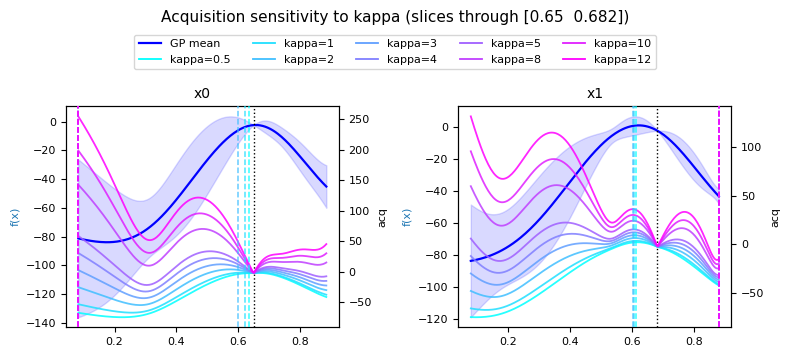

In [19]:
# both fits here, before any printing, so nothing interrupts the tables.
with fitting("kappa sweep + bounds cross-check"):
    kappa_rows = compare_kappa_proposals(
        X, y_logmag, bounds,
        kappa_values=[0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 8.0, 10.0, 12.0],
        maximize=True, n_restarts=60, random_state=0)
    x_corner, _ = generate_next_point(X, y_logmag, bounds_standard, acquisition="ucb",
                                      kappa=3.0, maximize=True, n_restarts=40,
                                      random_state=0)
in_data = bool(np.all(X.min(axis=0) <= x_corner) and np.all(x_corner <= X.max(axis=0)))

print_kappa_comparison(kappa_rows)

# Function-specific read: UCB on log10|y| maximises MAGNITUDE and is blind to
# sign, so we track how close each proposal drifts to the negative peak.
print(f"\n{'kappa':>6} {'x_next':>20} {'d(neg peak)':>12} {'d(incumbent)':>13}"
      f" {'nearest obs':>20} {'sign':>5} {'on box edge':>12}")
for r in kappa_rows:
    xn = np.asarray(r["x_next"])
    dists = np.linalg.norm(X - xn, axis=1)
    j = int(np.argmin(dists))
    edge = [f"x{k}" for k in range(D)
            if np.isclose(xn[k], bounds[k, 0], atol=1e-6)
            or np.isclose(xn[k], bounds[k, 1], atol=1e-6)]
    print(f"{r['kappa']:>6.1f} {str(np.round(xn, 4)):>20}"
          f" {np.linalg.norm(xn - neg_peak):>12.4f} {np.linalg.norm(xn - p_pos):>13.4f}"
          f" {str(np.round(X[j], 4)):>20} {'+' if y[j] > 0 else '-':>5}"
          f" {','.join(edge) or 'none':>12}")

# Evidence that the box-bounds choice is load-bearing rather than a
# preference: under padded bounds the same GP and kappa run off to the corner.
print(f"\nsame GP/kappa under bounds_standard would propose {np.round(x_corner, 4)}"
      f" -- inside the observed data: {in_data}")
print(f"  (bounds_standard upper corner is {np.round(bounds_standard[:, 1], 4)})")

fig = plot_kappa_sensitivity(X, y_logmag, bounds, gp_check, kappa_rows,
                             ucb_acquisition, maximize=True)
plt.show()

# My choice, defined here so we have one source of the value only 
KAPPA = 2.0



## Sign structure

Diagnostic only — nothing here changes the proposal. But `log10|y|` throws the sign away, so if I do not look at it separately it is invisible to me.

- **The magnitude peak is the wrong sign.** The largest `|y|` is `−3.6e-3`, 13 orders above anything else, so the region the surrogate finds most attractive is one I want to avoid.
- **Opposite-sign pairs bracket a zero contour.** Between any positive and any negative observation `y` must pass through zero. My closest such pair is 0.0959 apart — the incumbent and the magnitude peak are neighbours — so `max y` sits just on the positive side of that contour.

I also check whether the incumbent is a genuine local maximum or just a point near a zero crossing, via its leave-one-out z-score on `log10|y|`. A z near 0 means the smooth magnitude trend already accounts for it.

Remember: predicted magnitudes *inside* an opposite-sign pair: `|y| → 0` at the contour so `log10|y| → −∞`, and a smooth GP with no data in the gap cannot represent that dip. It will over-predict there, so we treat those numbers as upper bounds.

In [20]:
# Refit without the incumbent first (section 3 needs it) so the fit cannot
# interleave with what sections 1-2 print.
mask = np.ones(len(y), bool)
mask[i_pos_max] = False
with fitting("refit leaving the incumbent out"):
    gp_wo = fit_gp(X[mask], y_logmag[mask], bounds, n_restarts_optimizer=25,
                   random_state=0)
mu_wo, sd_wo = gp_wo.predict(normalize(p_pos.reshape(1, -1), bounds), return_std=True)
z_inc = float((y_logmag[i_pos_max] - mu_wo[0]) / sd_wo[0])
verdict = ("on the smooth magnitude trend; fast decay explains it" if abs(z_inc) < 1.0
           else "anomalous -- may sit near a zero contour")

print("=== 1. the magnitude peak is NEGATIVE ===")
print(f"  largest |y| : {np.round(neg_peak, 6)}  y = {y[i_abs_max]:+.4e}   <- what")
print("                log10|y| makes the GP chase, and the wrong sign")
print(f"  incumbent   : {np.round(p_pos, 6)}  y = {y[i_pos_max]:+.4e}   <- what we")
print("                are actually trying to beat")
print(f"  separation  : {np.linalg.norm(p_pos - neg_peak):.4f}"
      f"  ({np.log10(abs(y[i_abs_max] / y[i_pos_max])):.0f} orders of magnitude apart)")

print("\n=== 2. opposite-sign pairs: each brackets a zero contour ===")
pos_idx = np.flatnonzero(y > 0)
neg_idx = np.flatnonzero(y < 0)
pairs = sorted(((float(np.linalg.norm(X[i] - X[j])), i, j)
                for i in pos_idx for j in neg_idx))
for dist, i, j in pairs[:4]:
    print(f"  dist={dist:.4f}  +{np.round(X[i], 4)} (y={y[i]:+.2e})"
          f"  <->  -{np.round(X[j], 4)} (y={y[j]:+.2e})")
print("  -> max y lies just on the positive side of one of these contours;")
print("     nothing in the surrogate knows where they are.")

print("\n=== 3. is the incumbent a real local max, or just near a zero crossing? ===")
print(f"  actual log10|y| = {y_logmag[i_pos_max]:.2f},"
      f" predicted from the other {mask.sum()} = {mu_wo[0]:.2f} +/- {sd_wo[0]:.2f}")
print(f"  z = {z_inc:+.2f}  ->  {verdict}")

print("\n=== 4. sign counts, for the record ===")
print(f"  {len(pos_idx)} positive, {len(neg_idx)} negative."
      " A GP on sign(y) scores LOO R2 = -0.82 on this (see the evidence table),")
print("  so sign is measured, never predicted.")


[fitting: refit leaving the incumbent out] 1 warning held back:
     1 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
=== 1. the magnitude peak is NEGATIVE ===
  largest |y| : [0.650114 0.681526]  y = -3.6061e-03   <- what
                log10|y| makes the GP chase, and the wrong sign
  incumbent   : [0.677043 0.540748]  y = +6.8818e-08   <- what we
                are actually trying to beat
  separation  : 0.1433  (5 orders of magnitude apart)

=== 2. opposite-sign pairs: each brackets a zero contour ===
  dist=0.0959  +[0.731 0.733] (y=+7.71e-16)  <->  -[0.6501 0.6815] (y=-3.61e-03)
  dist=0.1029  +[0.8404 0.2647] (y=+3.34e-124)  <->  -[0.7606 0.1997] (y=-3.77e-115)
  dist=0.1433  +[0.677  0.5407] (y=+6.88e-08)  <->  -[0.6501 0.6815] (y=-3.61e-03)
  dist=0.1826  +[0.6834 0.8611] (y=+2.54e-40)  <->  -[0.6501 0.6815] (y=-3.61e-03)
  -> max y lies just on the positive side of one of these contours;
     nothing in the surrogate knows where they are.

=== 3.

## Propose the next point

Plain UCB argmax on the `log10|y|` surrogate at the chosen `KAPPA`. Two checks after it:

- **Convex-hull membership** — the strong extrapolation test, and the one I trust.
- **The sign of the nearest observations**, since my surrogate is sign-blind. This does not change the proposal; it tells me what to expect from the result.

In [21]:
with fitting("UCB proposal"):
    x_next, gp = generate_next_point(
        X, y_logmag, bounds,
        acquisition="ucb",
        kappa=KAPPA,        # see the comparison above
        maximize=True,
        n_restarts=25,
        random_state=0,
    )

print(f"--- Next point to evaluate (bounds shape {bounds.shape}) ---")
print("x_next:", np.round(x_next, 6))
print(gp.kernel_)

mu_log, sigma_log = gp.predict(normalize(x_next.reshape(1, -1), bounds), return_std=True)
print(f"\npredicted log10|y| = {mu_log[0]:+.3f} +/- {sigma_log[0]:.3f}"
      f"   -> |y| ~ 1e{mu_log[0]:.0f}")
print(f"largest |y| on record: {np.abs(y).max():.4e} (log10 = {y_logmag.max():.2f});"
      f" incumbent y = {y.max():.4e}")

print("\n--- extrapolation checks ---")
outside = [d for d in range(D) if not (X[:, d].min() <= x_next[d] <= X[:, d].max())]
print("outside the observed range on its own axis:", outside or "none")
on_edge = [f"x{d}" for d in range(D)
           if np.isclose(x_next[d], bounds[d, 0], atol=1e-6)
           or np.isclose(x_next[d], bounds[d, 1], atol=1e-6)]
print("on a box edge:", ",".join(on_edge) or "none")
print("inside the convex hull (the strong test):", bool(hull.find_simplex(x_next) >= 0))
print(f"distance from the incumbent: {np.linalg.norm(x_next - p_pos):.4f}")

print("\n--- sign-blindness check: what is nearby, and what sign is it? ---")
print(f"distance to the NEGATIVE magnitude peak: {np.linalg.norm(x_next - neg_peak):.4f}")
print("nearest 4 observations to x_next:")
for i in np.argsort(np.linalg.norm(X - x_next, axis=1))[:4]:
    print(f"  dist={np.linalg.norm(X[i] - x_next):.4f}  sign={'+' if y[i] > 0 else '-'}"
          f"  y={y[i]:+.4e}  x={np.round(X[i], 4)}")
n_neg_near = sum(1 for i in np.argsort(np.linalg.norm(X - x_next, axis=1))[:4] if y[i] < 0)
print(f"-> {n_neg_near} of the 4 nearest observations"
      f" {'is' if n_neg_near == 1 else 'are'} negative"
      + (", and it is the closest one" if n_neg_near and
         y[int(np.argmin(np.linalg.norm(X - x_next, axis=1)))] < 0 else "") + ".")
print("   UCB is maximising |y| and cannot see sign, so a negative result is a real")
print("   possibility here -- that is the cost of a magnitude-only surrogate.")

# fixed gates: I never submit a point outside the data cloud or outside the
# domain.
assert bool(hull.find_simplex(x_next) >= 0), "x_next is outside the convex hull"
assert np.all(x_next >= 0.0), "X is never negative -- proposal has a negative coordinate"


[fitting: UCB proposal] 1 warning held back:
     1 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
--- Next point to evaluate (bounds shape (2, 2)) ---
x_next: [0.598885 0.602451]
1.18**2 * Matern(length_scale=[0.346, 0.424], nu=2.5) + WhiteKernel(noise_level=1e-06)

predicted log10|y| = -1.553 +/- 5.276   -> |y| ~ 1e-2
largest |y| on record: 3.6061e-03 (log10 = -2.44); incumbent y = 6.8818e-08

--- extrapolation checks ---
outside the observed range on its own axis: none
on a box edge: none
inside the convex hull (the strong test): True
distance from the incumbent: 0.0996

--- sign-blindness check: what is nearby, and what sign is it? ---
distance to the NEGATIVE magnitude peak: 0.0942
nearest 4 observations to x_next:
  dist=0.0942  sign=-  y=-3.6061e-03  x=[0.6501 0.6815]
  dist=0.0996  sign=+  y=+6.8818e-08  x=[0.677  0.5407]
  dist=0.1268  sign=+  y=+8.2725e-14  x=[0.5339 0.4936]
  dist=0.1858  sign=+  y=+7.7109e-16  x=[0.731 0.733]
-> 1 of the 4 neares

## Visualise the GP and acquisition function

Panels are in **`log10|y|` units**, not `y`.

Two things I look for. The GP mean panel should show a single tight peak near (0.65, 0.68) — that is the magnitude peak, and it is the *negative* observation. And the markers should make the sign structure visible: the peak and my incumbent are neighbours with opposite signs, so a zero contour runs between them, and the dashed line marks that pair. `x_next` is UCB's argmax and is not placed relative to it.

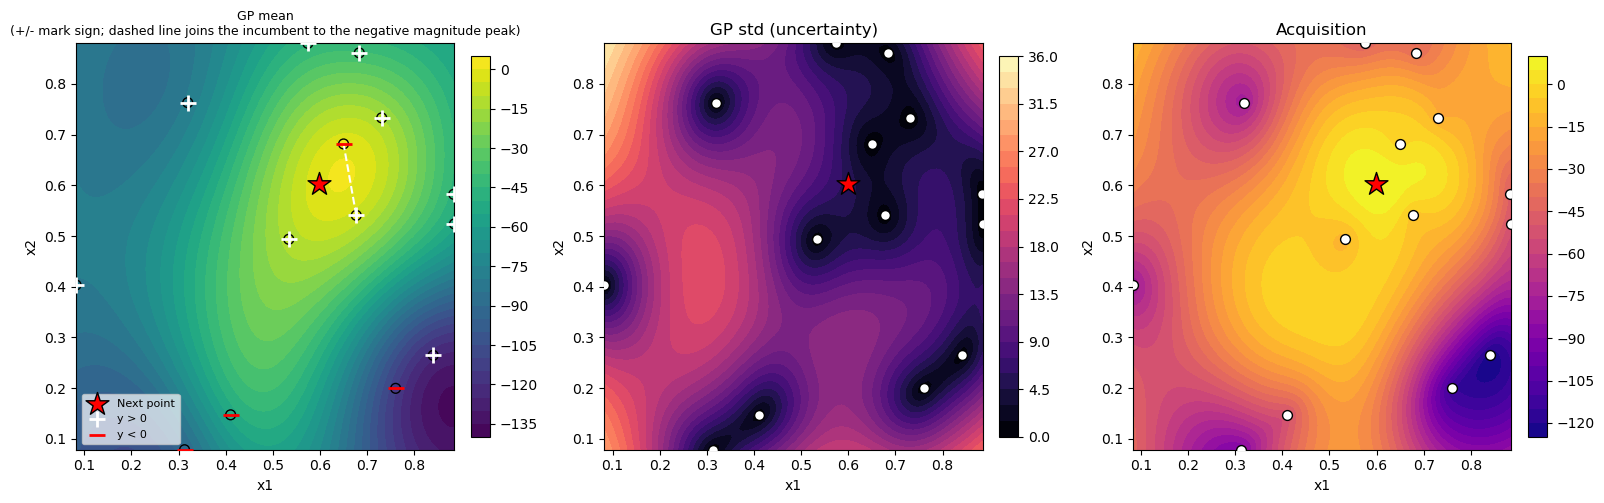

In [22]:
fig = plot_2d_bo(
    X, y_logmag, bounds, gp,
    acquisition_fn=ucb_acquisition,
    x_next=x_next,
    acq_kwargs={"kappa": KAPPA, "maximize": True},
    y_scale=None,   # panels are log10|y|; a linear y_scale does not apply here
)

# I mark the sign structure; the colour scale alone cannot show it.
ax = fig.axes[0]
ax.scatter(X[y > 0, 0], X[y > 0, 1], marker="+", s=140, c="white", linewidths=2.0,
           label="y > 0", zorder=6)
ax.scatter(X[y < 0, 0], X[y < 0, 1], marker="_", s=140, c="red", linewidths=2.0,
           label="y < 0", zorder=6)
ax.plot([p_pos[0], neg_peak[0]], [p_pos[1], neg_peak[1]], "w--", lw=1.5, zorder=5)
ax.legend(loc="lower left", fontsize=8, framealpha=0.7)
ax.set_title(ax.get_title() + "\n(+/- mark sign; dashed line joins the incumbent"
             " to the negative magnitude peak)", fontsize=9)
plt.show()


## Sanity-check the surrogate: leave-one-out calibration

The numbers are in the evidence table above; this is the visual version. I want points scattered about the diagonal with error bars that actually cover it.

[fitting: leave-one-out for the calibration plot] 14 warnings held back:
    14 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06


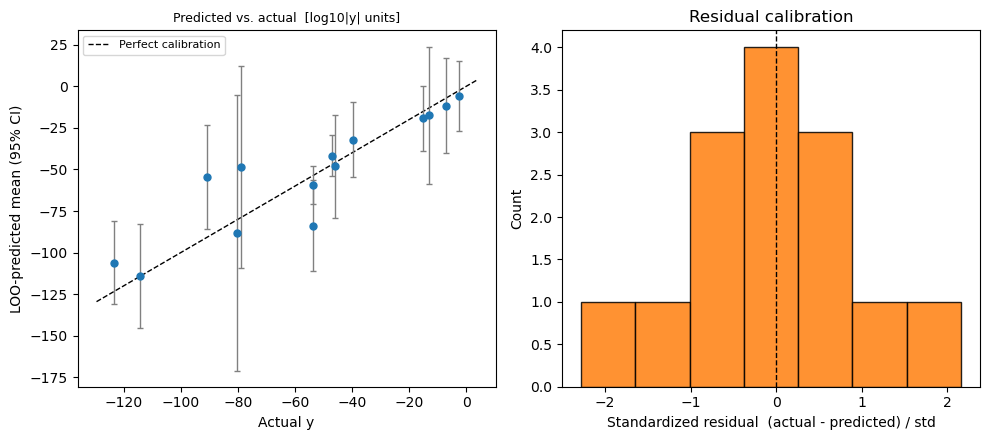

mean|z| = 0.78 (1.0 is ideal) | max|z| = 2.28
within 1 sigma: 11/14 | within 2 sigma: 12/14
worst-predicted point: x=[0.3127 0.0787] sign=- actual log10|y|=-90.7 predicted=-54.3 (z=-2.28)


In [23]:
with fitting("leave-one-out for the calibration plot"):
    pred_mean_log, pred_std_log = loo_predictions(
        X, y_logmag, bounds, gp_kwargs={"n_restarts_optimizer": 20})

# I do not pass y_scale: these are log10|y| units, not a rescale of y.
fig = plot_loo_calibration(y_logmag, pred_mean_log, pred_std_log)
for ax in np.atleast_1d(fig.axes).ravel()[:1]:
    ax.set_title(ax.get_title() + "  [log10|y| units]", fontsize=9)
plt.show()

z = (y_logmag - pred_mean_log) / pred_std_log
print(f"mean|z| = {np.abs(z).mean():.2f} (1.0 is ideal) | max|z| = {np.abs(z).max():.2f}")
print(f"within 1 sigma: {int((np.abs(z) <= 1).sum())}/{len(z)}"
      f" | within 2 sigma: {int((np.abs(z) <= 2).sum())}/{len(z)}")
worst = int(np.argmax(np.abs(z)))
print(f"worst-predicted point: x={np.round(X[worst], 4)} sign={'+' if y[worst] > 0 else '-'}"
      f" actual log10|y|={y_logmag[worst]:.1f} predicted={pred_mean_log[worst]:.1f}"
      f" (z={z[worst]:+.2f})")


In [24]:
# The proposal as a hyphen-separated string, for submission.
print("-".join(f"{v:.6f}" for v in x_next))

# Full precision too. I submit the 6-dp string; the store keeps 6 dp as well,
# which is what was actually evaluated.
print("\nfull precision (use for next week's new_X):")
print("-".join(repr(float(v)) for v in x_next))



0.598885-0.602451

full precision (use for next week's new_X):
0.5988849367958297-0.6024505787039317


In [25]:
# I record this week's proposal in the weekly store. This rewrites
# inputs.csv rather than appending, so re-running the notebook cannot
# double-record. I submit the 6-dp string printed above -- it is the same value
# written here.
save_proposal(1, new_X, x_next)


wrote weekly_data/function_1/inputs.csv: 5 row(s) (4 resulted + 1 proposal)
  proposal row: 0.5988849367958297-0.6024505787039317


'weekly_data/function_1/inputs.csv'